In [4]:
# =======================================================
# Ejemplo completo: Pruebas de Stress en Forecasting de Ventas en Cadenas de Farmacias
# Simulación de base de datos profesional con 18 variables (macro, operativas, estacionales)
# Usa HistGradientBoostingRegressor (histogram-based gradient boosting) para forecasting
# Incluye: EDA, predicciones con exógenas/futuras, stress testing (crisis económica, cambios demanda)
# Comentarios detallados en cada sección
# =======================================================
# Requisitos: pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_hist_gradient_boosting  # Necesario para HistGradientBoosting
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE
from neuralforecast.losses.numpy import mae, rmse
import warnings
warnings.filterwarnings('ignore')

## `Informacion del dataset`
- sales_volume: Ventas mensuales (unidades)
- price_avg: Precio promedio ($)
- cost_avg: Costo promedio ($)
- revenue: Ingresos mensuales ($)
- season_factor: Seasonalidad (e.g., invierno más ventas)
- promotion_active: Promociones
- holiday_factor: Feriados diciembre
- inflation_rate: Inflación (%)
- economic_index: Índice económico
- unemployment_rate: Desempleo (%)
- customer_traffic: Tráfico clientes
- competitor_price_index: Índice precio competidores
- marketing_spend: Gasto marketing ($)
- stockouts: Stockouts mensuales
- returns_rate: Tasa devoluciones
- supplier_delay: Días retraso proveedor
- weather_impact: Impacto clima

In [5]:
# cargar datos
df = pd.read_csv('Ventas_Cadenas_Farmacias.csv', parse_dates= ['ds'])
df

,store_id,ds,sales_volume,price_avg,cost_avg,revenue,season_factor,promotion_active,holiday_factor,inflation_rate,economic_index,unemployment_rate,customer_traffic,competitor_price_index,marketing_spend,stockouts,returns_rate,supplier_delay,weather_impact,y
0,Farmacia_1,2015-01-01,4974,48.00,30.2400,238752.00,2.000000,0,1,1.869385,99.935369,4.417480,10036,0.974689,8902.968752,1,0.032773,0,0.963064,9718
1,Farmacia_1,2015-02-01,5049,5.82,4.4814,29385.18,2.366025,0,1,3.622711,99.908760,4.541571,10096,0.976707,11512.812244,0,0.037705,0,1.022964,11559
2,Farmacia_1,2015-03-01,4919,13.81,8.9765,67931.39,2.500000,0,1,3.629530,99.878393,5.950492,9987,1.067324,11564.348197,2,0.033688,3,0.901242,11844
3,Farmacia_1,2015-04-01,5020,5.34,4.1118,26806.80,2.366025,1,1,2.195684,99.874532,3.952700,9872,1.030158,14010.907221,2,0.045148,3,0.843139,14491
4,Farmacia_1,2015-05-01,5077,34.14,22.5324,173328.78,2.000000,1,1,3.895355,99.895824,7.518012,10013,1.022834,9753.238901,3,0.024276,1,0.893553,12151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,Farmacia_5,2025-08-01,5004,10.68,6.6216,53442.72,0.633975,0,1,2.167939,98.952838,5.710111,9930,1.005967,9917.847039,2,0.022786,3,0.837411,3051
656,Farmacia_5,2025-09-01,4976,35.43,24.4467,176299.68,0.500000,0,1,2.449885,98.930541,5.436421,10031,0.957997,15859.321595,1,0.025244,3,0.996886,2391
657,Farmacia_5,2025-10-01,5016,19.63,11.9743,98464.08,0.633975,0,1,2.852975,98.936198,6.436759,9915,1.025781,12060.869896,1,0.034548,3,1.033420,3041
658,Farmacia_5,2025-11-01,5022,35.88,25.1160,180189.36,1.000000,0,1,3.840734,98.918042,3.813677,9994,0.923588,14608.183545,2,0.034945,0,0.862474,4816


In [3]:
df['ds'] =  pd.to_datetime(df['ds'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   store_id                660 non-null    object        
 1   ds                      660 non-null    datetime64[ns]
 2   sales_volume            660 non-null    int64         
 3   price_avg               660 non-null    float64       
 4   cost_avg                660 non-null    float64       
 5   revenue                 660 non-null    float64       
 6   season_factor           660 non-null    float64       
 7   promotion_active        660 non-null    int64         
 8   holiday_factor          660 non-null    int64         
 9   inflation_rate          660 non-null    float64       
 10  economic_index          660 non-null    float64       
 11  unemployment_rate       660 non-null    float64       
 12  customer_traffic        660 non-null    int64     

In [5]:
# =======================================================
# 2. Análisis Exploratorio de Datos (EDA)
# =======================================================
print("\n=== EDA General ===")
print(df.describe())


=== EDA General ===
                                  ds  sales_volume   price_avg    cost_avg  \
count                            660    660.000000  660.000000  660.000000   
mean   2020-06-16 02:10:54.545454592   4997.368182   27.484015   19.226381   
min              2015-01-01 00:00:00   4780.000000    5.140000    3.360400   
25%              2017-09-23 12:00:00   4945.000000   15.845000   11.186900   
50%              2020-06-16 00:00:00   4998.500000   27.900000   19.290000   
75%              2023-03-08 18:00:00   5045.000000   38.727500   26.512600   
max              2025-12-01 00:00:00   5222.000000   49.930000   38.962800   
std                              NaN     73.734972   12.979597    9.286496   

             revenue  season_factor  promotion_active  holiday_factor  \
count     660.000000     660.000000        660.000000      660.000000   
mean   137344.927288       1.500000          0.300000        1.083333   
min     25859.340000       0.500000          0.000000    

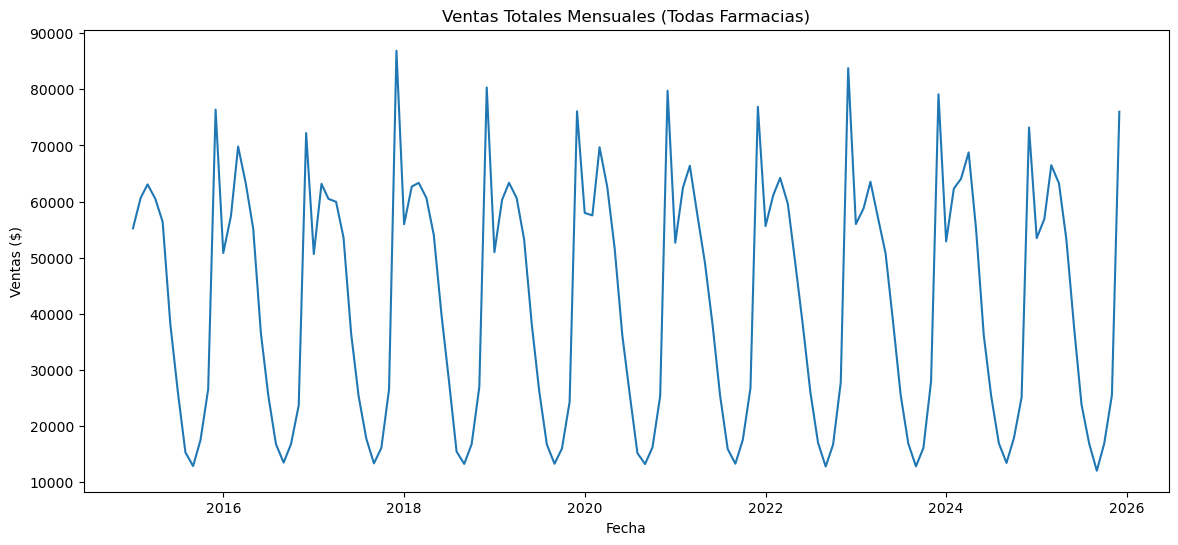

In [6]:
# Tendencia ventas totales
df_agg = df.groupby('ds')['y'].sum().reset_index()
plt.figure(figsize=(14,6))
plt.plot(df_agg['ds'], df_agg['y'])
plt.title('Ventas Totales Mensuales (Todas Farmacias)')
plt.xlabel('Fecha')
plt.ylabel('Ventas ($)')
plt.show()

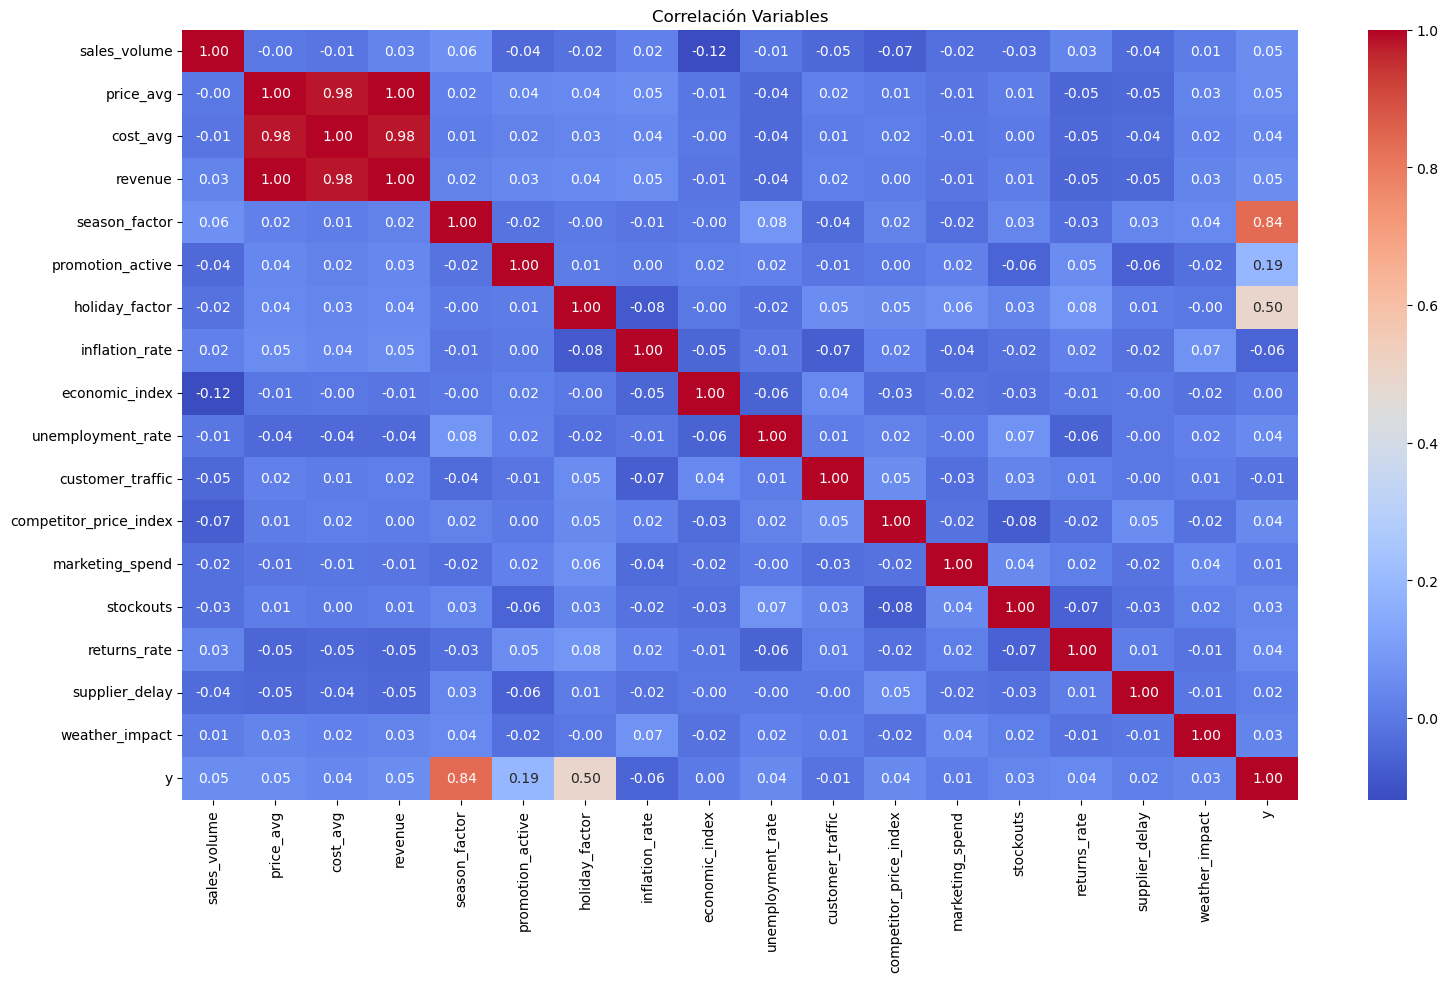

In [7]:
# Correlación variables
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación Variables')
plt.show()

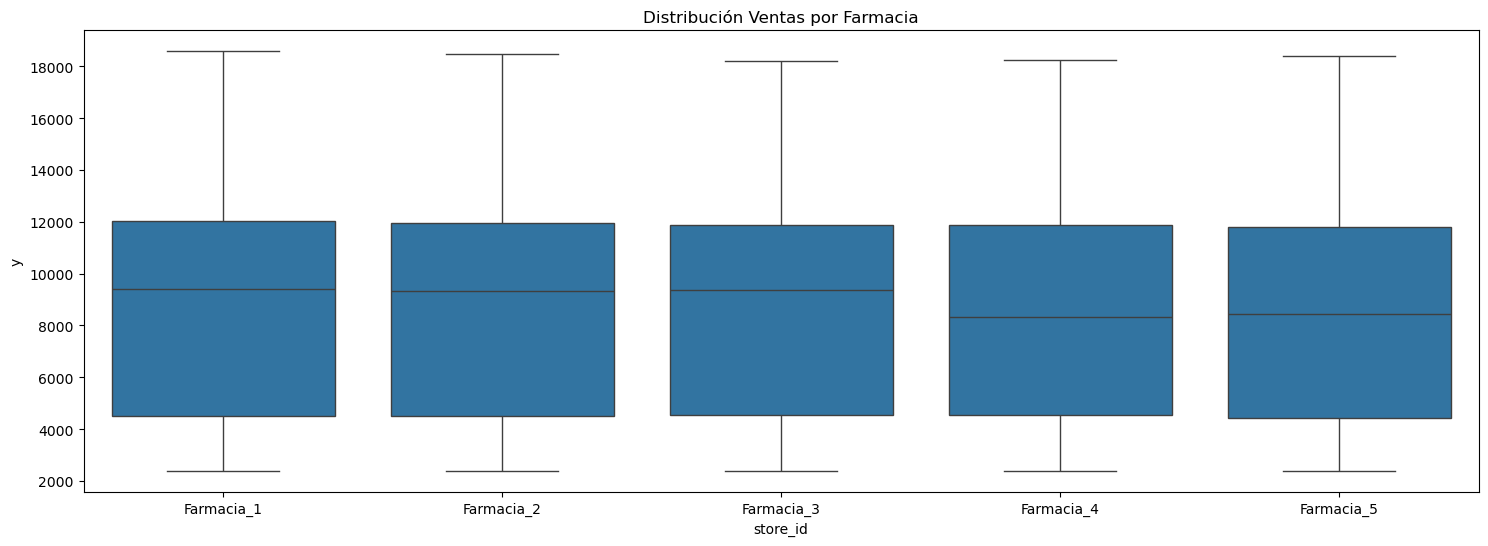

In [8]:
# Ventas por tienda
plt.figure(figsize=(18,6))
sns.boxplot(x='store_id', y='y', data=df)
plt.title('Distribución Ventas por Farmacia')
plt.show()

In [9]:
# =======================================================
# 3. Preparación de datos para forecasting
# =======================================================
# Multi-series: unique_id = store_id, y = ventas
df_ts = df[['store_id', 'ds', 'y', 'season_factor', 'promotion_active', 'inflation_rate', 'economic_index', 'unemployment_rate']].copy()
df_ts = df_ts.rename(columns={'store_id': 'unique_id'})

exog_cols = ['season_factor', 'promotion_active', 'inflation_rate', 'economic_index', 'unemployment_rate']

df_ts

,unique_id,ds,y,season_factor,promotion_active,inflation_rate,economic_index,unemployment_rate
0,Farmacia_1,2015-01-01,9718,2.000000,0,1.869385,99.935369,4.417480
1,Farmacia_1,2015-02-01,11559,2.366025,0,3.622711,99.908760,4.541571
2,Farmacia_1,2015-03-01,11844,2.500000,0,3.629530,99.878393,5.950492
3,Farmacia_1,2015-04-01,14491,2.366025,1,2.195684,99.874532,3.952700
4,Farmacia_1,2015-05-01,12151,2.000000,1,3.895355,99.895824,7.518012
...,...,...,...,...,...,...,...,...
655,Farmacia_5,2025-08-01,3051,0.633975,0,2.167939,98.952838,5.710111
656,Farmacia_5,2025-09-01,2391,0.500000,0,2.449885,98.930541,5.436421
657,Farmacia_5,2025-10-01,3041,0.633975,0,2.852975,98.936198,6.436759
658,Farmacia_5,2025-11-01,4816,1.000000,0,3.840734,98.918042,3.813677


In [10]:
# Train/test
train_df = df_ts[df_ts['ds'] < '2024-01-01']
test_df = df_ts[df_ts['ds'] >= '2024-01-01']

train_df.shape, test_df.shape

((540, 8), (120, 8))

In [16]:
# Future exog (extender último valor con ruido para escenarios base)
futr_df = pd.DataFrame()
for uid in train_df['unique_id'].unique():
    last_row = train_df[train_df['unique_id'] == uid].iloc[-1]
    future_dates = pd.date_range('2024-01-01', '2026-12-01', freq='MS')
    futr_uid = pd.DataFrame({
        'unique_id': [uid] * len(future_dates),
        'ds': future_dates
    })
    for col in exog_cols:
        last_val = last_row[col]
        futr_uid[col] = last_val * np.random.uniform(0.95, 1.05, len(future_dates))  # Variación ±5%
    futr_df = pd.concat([futr_df, futr_uid])

futr_df

,unique_id,ds,season_factor,promotion_active,inflation_rate,economic_index,unemployment_rate
0,Farmacia_1,2024-01-01,1.457441,0.0,2.718951,104.453086,5.288272
1,Farmacia_1,2024-02-01,1.528743,0.0,2.700195,103.169928,5.408314
2,Farmacia_1,2024-03-01,1.443180,0.0,2.792132,96.834997,5.448292
3,Farmacia_1,2024-04-01,1.434317,0.0,2.745335,98.606461,5.769818
4,Farmacia_1,2024-05-01,1.483228,0.0,2.562981,96.787280,5.376098
...,...,...,...,...,...,...,...
31,Farmacia_5,2026-08-01,1.487726,0.0,2.898039,96.227469,5.629798
32,Farmacia_5,2026-09-01,1.500156,0.0,3.004591,96.672479,5.416015
33,Farmacia_5,2026-10-01,1.518624,0.0,2.984846,100.840718,5.708997
34,Farmacia_5,2026-11-01,1.528615,0.0,3.057334,103.444059,5.602030


In [19]:
# horizonte
horizon = len(futr_df['ds'].unique())

In [21]:
# =======================================================
# 4. Forecasting con NeuralForecast (multi-series, exógenas)
# =======================================================
models = [NHITS(h=horizon, input_size= horizon * 2, futr_exog_list=exog_cols, loss=MAE(), max_steps=300, random_seed=42)]

nf = NeuralForecast(models=models, freq='MS')
nf.fit(df=train_df)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.1 M  | train
-------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.541    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 34.47it/s, v_num=273, train_loss_step=566.0, train_loss_epoch=566.0]   

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 32.51it/s, v_num=273, train_loss_step=566.0, train_loss_epoch=566.0]


In [22]:
forecast = nf.predict(futr_df=futr_df)
forecast

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 20.78it/s]


,unique_id,ds,NHITS
0,Farmacia_1,2024-01-01,10864.875000
1,Farmacia_1,2024-02-01,11240.731445
2,Farmacia_1,2024-03-01,11586.429688
3,Farmacia_1,2024-04-01,10962.699219
4,Farmacia_1,2024-05-01,9425.023438
...,...,...,...
175,Farmacia_5,2026-08-01,3024.950195
176,Farmacia_5,2026-09-01,2375.630859
177,Farmacia_5,2026-10-01,3195.458984
178,Farmacia_5,2026-11-01,6015.985840


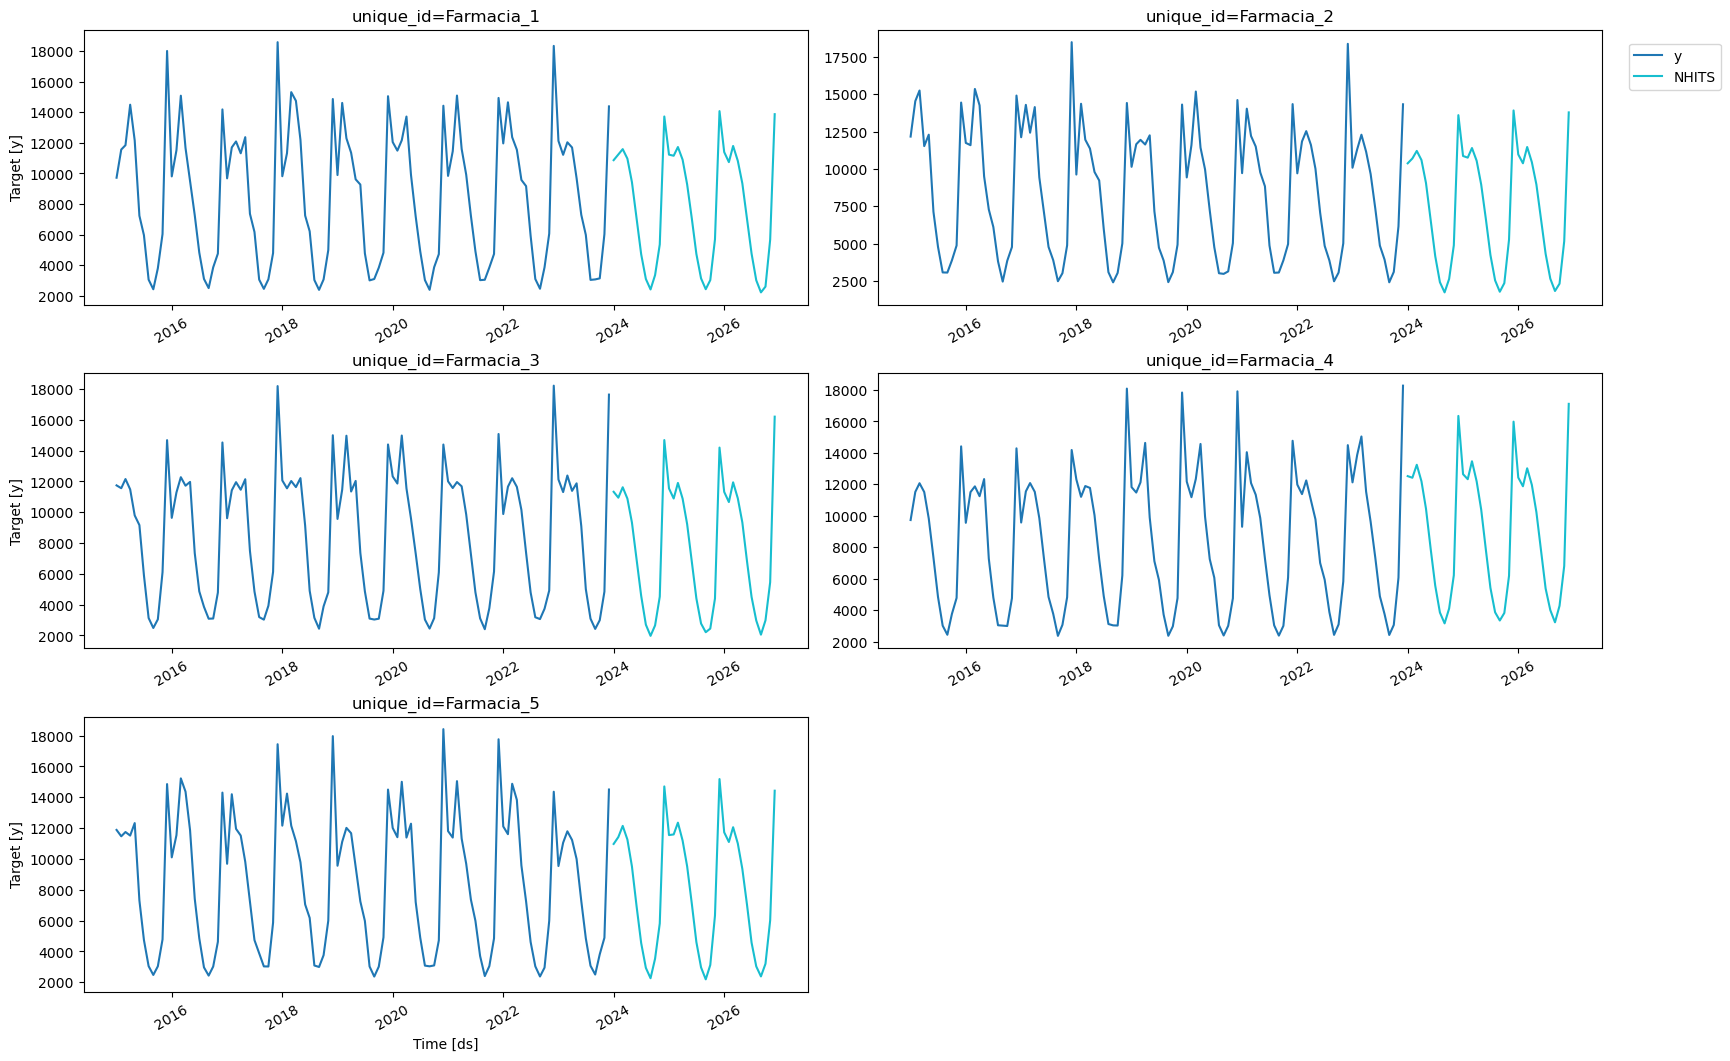

In [24]:
from utilsforecast.plotting import plot_series
plot_series(train_df, forecast)

In [49]:
# Métricas base
y_true = test_df['y']
y_pred = forecast[forecast['ds'] < '2026-01-01']
mae = mean_absolute_error(y_true, y_pred['NHITS'])
rmse = mean_squared_error(y_true, y_pred['NHITS'],)
mape = mean_absolute_percentage_error(y_true, y_pred['NHITS']) * 100

print("\n=== Métricas Forecasting Base ===")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")


=== Métricas Forecasting Base ===
MAE: 1034.66, RMSE: 2003632.75, MAPE: 13.17%


In [50]:
# Agregar forecast al DF principal (merge por store_id/ds)
forecast = forecast.rename(columns={'unique_id': 'store_id'})
df_forecast = forecast[['store_id', 'ds', 'NHITS']].rename(columns={'NHITS': 'forecast_sales'})
df_forecast

,store_id,ds,forecast_sales
0,Farmacia_1,2024-01-01,10864.875000
1,Farmacia_1,2024-02-01,11240.731445
2,Farmacia_1,2024-03-01,11586.429688
3,Farmacia_1,2024-04-01,10962.699219
4,Farmacia_1,2024-05-01,9425.023438
...,...,...,...
175,Farmacia_5,2026-08-01,3024.950195
176,Farmacia_5,2026-09-01,2375.630859
177,Farmacia_5,2026-10-01,3195.458984
178,Farmacia_5,2026-11-01,6015.985840


In [51]:
# =======================================================
# 5. Pruebas de Stress: Escenarios de crisis económica / cambios demanda
# =======================================================
# Escenario 1: Crisis económica (unemployment +20%, economic_index -15%, inflation +10%)
futr_df_crisis = futr_df.copy()
futr_df_crisis['unemployment_rate'] *= 1.2
futr_df_crisis['economic_index'] *= 0.85
futr_df_crisis['inflation_rate'] *= 1.1

futr_df_crisis

,unique_id,ds,season_factor,promotion_active,inflation_rate,economic_index,unemployment_rate
0,Farmacia_1,2024-01-01,1.457441,0.0,2.990846,88.785123,6.345926
1,Farmacia_1,2024-02-01,1.528743,0.0,2.970214,87.694439,6.489977
2,Farmacia_1,2024-03-01,1.443180,0.0,3.071345,82.309748,6.537951
3,Farmacia_1,2024-04-01,1.434317,0.0,3.019869,83.815492,6.923781
4,Farmacia_1,2024-05-01,1.483228,0.0,2.819279,82.269188,6.451318
...,...,...,...,...,...,...,...
31,Farmacia_5,2026-08-01,1.487726,0.0,3.187843,81.793349,6.755758
32,Farmacia_5,2026-09-01,1.500156,0.0,3.305051,82.171607,6.499217
33,Farmacia_5,2026-10-01,1.518624,0.0,3.283330,85.714610,6.850796
34,Farmacia_5,2026-11-01,1.528615,0.0,3.363067,87.927450,6.722436


In [52]:
forecast_crisis = nf.predict(futr_df=futr_df_crisis)
forecast_crisis

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 47.02it/s]


,unique_id,ds,NHITS
0,Farmacia_1,2024-01-01,10859.687500
1,Farmacia_1,2024-02-01,11227.087891
2,Farmacia_1,2024-03-01,11570.704102
3,Farmacia_1,2024-04-01,10952.682617
4,Farmacia_1,2024-05-01,9415.182617
...,...,...,...
175,Farmacia_5,2026-08-01,3014.330566
176,Farmacia_5,2026-09-01,2359.512695
177,Farmacia_5,2026-10-01,3176.103516
178,Farmacia_5,2026-11-01,5992.736816


In [53]:
delta_crisis = (forecast_crisis['NHITS'].mean() - forecast['NHITS'].mean()) / forecast['NHITS'].mean() * 100
print(f"\nStress Crisis Económica: Ventas promedio caen {delta_crisis:.2f}%")


Stress Crisis Económica: Ventas promedio caen -0.16%


In [54]:
# Escenario 2: Cambio demanda (promotion_active = 1 siempre, season_factor +10%)
futr_df_demand = futr_df.copy()
futr_df_demand['promotion_active'] = 1
futr_df_demand['season_factor'] *= 1.1

forecast_demand = nf.predict(futr_df=futr_df_demand)

delta_demand = (forecast_demand['NHITS'].mean() - forecast['NHITS'].mean()) / forecast['NHITS'].mean() * 100
print(f"Stress Cambio Demanda: Ventas promedio suben {delta_demand:.2f}%")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 117.23it/s]
Stress Cambio Demanda: Ventas promedio suben 0.03%


In [55]:




# Agregar forecasts de stress al DF forecast
df_forecast['forecast_crisis'] = forecast_crisis['NHITS']
df_forecast['forecast_demand_change'] = forecast_demand['NHITS']

# Merge forecasts al DF original (para análisis)
df = df.merge(df_forecast, left_on=['store_id', 'ds'], right_on=['store_id', 'ds'], how='left')

print("\nDF con forecasts agregados (muestra futura):")
print(df[df['ds'] >= '2024-01-01'].head())

print("\n¡Análisis completo terminado!")
print("Forecasting con HistGradientBoosting para ventas en farmacias.")
print("Stress testing simula escenarios para evaluar impacto en predicciones.")


DF con forecasts agregados (muestra futura):
       store_id         ds  sales_volume  price_avg  cost_avg    revenue  \
108  Farmacia_1 2024-01-01          5084      25.93   16.8545  131828.12   
109  Farmacia_1 2024-02-01          4923       7.71    5.1657   37956.33   
110  Farmacia_1 2024-03-01          5139      30.30   20.9070  155711.70   
111  Farmacia_1 2024-04-01          5014      48.09   29.3349  241123.26   
112  Farmacia_1 2024-05-01          4913      12.89    8.1207   63328.57   

     season_factor  promotion_active  holiday_factor  inflation_rate  ...  \
108       2.000000                 0               1        2.161414  ...   
109       2.366025                 0               1        2.113319  ...   
110       2.500000                 0               1        3.534817  ...   
111       2.366025                 1               1        4.228981  ...   
112       2.000000                 1               1        2.362692  ...   

     competitor_price_index  marke

In [56]:
df

,store_id,ds,sales_volume,price_avg,cost_avg,revenue,season_factor,promotion_active,holiday_factor,inflation_rate,...,competitor_price_index,marketing_spend,stockouts,returns_rate,supplier_delay,weather_impact,y,forecast_sales,forecast_crisis,forecast_demand_change
0,Farmacia_1,2015-01-01,4974,48.00,30.2400,238752.00,2.000000,0,1,1.869385,...,0.974689,8902.968752,1,0.032773,0,0.963064,9718,NaN,NaN,NaN
1,Farmacia_1,2015-02-01,5049,5.82,4.4814,29385.18,2.366025,0,1,3.622711,...,0.976707,11512.812244,0,0.037705,0,1.022964,11559,NaN,NaN,NaN
2,Farmacia_1,2015-03-01,4919,13.81,8.9765,67931.39,2.500000,0,1,3.629530,...,1.067324,11564.348197,2,0.033688,3,0.901242,11844,NaN,NaN,NaN
3,Farmacia_1,2015-04-01,5020,5.34,4.1118,26806.80,2.366025,1,1,2.195684,...,1.030158,14010.907221,2,0.045148,3,0.843139,14491,NaN,NaN,NaN
4,Farmacia_1,2015-05-01,5077,34.14,22.5324,173328.78,2.000000,1,1,3.895355,...,1.022834,9753.238901,3,0.024276,1,0.893553,12151,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,Farmacia_5,2025-08-01,5004,10.68,6.6216,53442.72,0.633975,0,1,2.167939,...,1.005967,9917.847039,2,0.022786,3,0.837411,3051,2959.698730,2947.777344,2963.400879
656,Farmacia_5,2025-09-01,4976,35.43,24.4467,176299.68,0.500000,0,1,2.449885,...,0.957997,15859.321595,1,0.025244,3,0.996886,2391,2186.247070,2173.183105,2190.033691
657,Farmacia_5,2025-10-01,5016,19.63,11.9743,98464.08,0.633975,0,1,2.852975,...,1.025781,12060.869896,1,0.034548,3,1.033420,3041,3117.798828,3099.938477,3122.224609
658,Farmacia_5,2025-11-01,5022,35.88,25.1160,180189.36,1.000000,0,1,3.840734,...,0.923588,14608.183545,2,0.034945,0,0.862474,4816,6320.004883,6297.749023,6325.058594


otro ejemplo

In [ ]:
# =======================================================
# Ejemplo completo: Pruebas de Stress en Forecasting de Ventas en Cadenas de Farmacias
# Simulación de base de datos profesional con 18 variables (macro, operativas, estacionales)
# Usa CatBoostRegressor para forecasting (potente para datos tabulares con exógenas)
# Incluye: EDA, predicciones con exógenas/futuras, stress testing (crisis económica, cambios demanda)
# No usa NeuralForecast, como solicitado
# =======================================================
# Requisitos: pip install pandas numpy matplotlib seaborn catboost scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. Simulación de base de datos profesional desde cero
# =======================================================
# Creamos datos mensuales desde 2015 hasta 2025 (120 meses) para 5 farmacias (total ~600 registros, escalable)
# 18 variables: ventas, costos, stock, exógenas macro (índice económico, inflación), estacionales, etc.
# Para stress: variables como 'economic_index' para escenarios de crisis
np.random.seed(42)
dates = pd.date_range('2015-01-01', '2025-12-01', freq='M')
n_periods = len(dates)
n_stores = 5  # Cadenas de farmacias
stores = [f'Farmacia_{i+1}' for i in range(n_stores)]

# Crear DF multi-store
index = pd.MultiIndex.from_product([stores, dates], names=['store_id', 'ds'])
df = pd.DataFrame(index=index).reset_index()

# Variables base (18 total)
df['sales_volume'] = np.random.poisson(5000, len(df)).clip(3000, 12000).astype(int)  # Ventas mensuales (unidades)
df['price_avg'] = np.random.uniform(5, 50, len(df)).round(2)  # Precio promedio ($)
df['cost_avg'] = df['price_avg'] * np.random.uniform(0.6, 0.8, len(df)).round(2)  # Costo promedio ($)
df['revenue'] = df['sales_volume'] * df['price_avg']  # Ingresos mensuales ($)
df['season_factor'] = np.sin(2 * np.pi * df['ds'].dt.month / 12) + 1.5  # Seasonalidad (e.g., invierno más ventas)
df['promotion_active'] = np.random.choice([0, 1], len(df), p=[0.7, 0.3])  # Promociones
df['holiday_factor'] = (df['ds'].dt.month == 12).astype(int) + 1  # Feriados diciembre
df['inflation_rate'] = np.random.normal(3, 1, len(df)).clip(1, 6)  # Inflación (%)
df['economic_index'] = np.cumsum(np.random.normal(0, 0.05, len(df))) + 100  # Índice económico
df['unemployment_rate'] = np.random.normal(5, 1.5, len(df)).clip(3, 8)  # Desempleo (%)
df['customer_traffic'] = np.random.poisson(10000, len(df)).clip(8000, 20000)  # Tráfico clientes
df['competitor_price_index'] = np.random.uniform(0.9, 1.1, len(df))  # Índice precio competidores
df['marketing_spend'] = np.random.normal(10000, 3000, len(df)).clip(5000, 20000)  # Gasto marketing ($)
df['stockouts'] = np.random.poisson(2, len(df))  # Stockouts mensuales
df['returns_rate'] = np.random.uniform(0.01, 0.05, len(df))  # Tasa devoluciones
df['supplier_delay'] = np.random.choice([0, 1, 2, 3], len(df))  # Días retraso proveedor
df['weather_impact'] = np.random.normal(1, 0.1, len(df)).clip(0.8, 1.2)  # Impacto clima

# Ajustar ventas con lógica
df['y'] = (df['sales_volume'] * df['season_factor'] * (1 + df['promotion_active']*0.25) * df['holiday_factor'] * 
           (1 - df['inflation_rate']/100 * 0.5) * (df['economic_index']/100) * (1 - df['unemployment_rate']/100 * 0.3)).astype(int).clip(2000)

print(f"Dataset creado: {df.shape[0]} filas, {df.shape[1]} columnas (18 variables)")

# =======================================================
# 2. Análisis Exploratorio de Datos (EDA)
# =======================================================
print("\n=== EDA General ===")
print(df.describe())

# Tendencia ventas totales
df_agg = df.groupby('ds')['y'].sum().reset_index()
plt.figure(figsize=(14,6))
plt.plot(df_agg['ds'], df_agg['y'])
plt.title('Ventas Totales Mensuales (Todas Farmacias)')
plt.xlabel('Fecha')
plt.ylabel('Ventas ($)')
plt.show()

# Correlación variables
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación Variables')
plt.show()

# Ventas por tienda
plt.figure(figsize=(12,6))
sns.boxplot(x='store_id', y='y', data=df)
plt.title('Distribución Ventas por Farmacia')
plt.show()

# =======================================================
# 3. Preparación de datos para forecasting
# =======================================================
# Multi-series: unique_id = store_id, y = ventas
df_ts = df[['store_id', 'ds', 'y', 'season_factor', 'promotion_active', 'inflation_rate', 'economic_index', 'unemployment_rate']].copy()
df_ts = df_ts.rename(columns={'store_id': 'unique_id'})

exog_cols = ['season_factor', 'promotion_active', 'inflation_rate', 'economic_index', 'unemployment_rate']

# Train/test
train_df = df_ts[df_ts['ds'] < '2024-01-01']
test_df = df_ts[df_ts['ds'] >= '2024-01-01']

horizon = len(test_df['ds'].unique())

# Future exog (extender último valor con ruido para escenarios base)
futr_df = pd.DataFrame()
for uid in train_df['unique_id'].unique():
    last_row = train_df[train_df['unique_id'] == uid].iloc[-1]
    future_dates = pd.date_range('2024-01-01', '2025-12-01', freq='M')
    futr_uid = pd.DataFrame({
        'unique_id': [uid] * horizon,
        'ds': future_dates
    })
    for col in exog_cols:
        last_val = last_row[col]
        futr_uid[col] = last_val * np.random.uniform(0.95, 1.05, horizon)  # Variación ±5%
    futr_df = pd.concat([futr_df, futr_uid])

# =======================================================
# 4. Forecasting con HistGradientBoostingRegressor (por serie para multi-series)
# =======================================================
forecasts = pd.DataFrame()
for uid in train_df['unique_id'].unique():
    train_uid = train_df[train_df['unique_id'] == uid]
    test_uid = test_df[test_df['ds'] >= '2024-01-01']

    X_train = train_uid[exog_cols]
    y_train = train_uid['y']

    model = HistGradientBoostingRegressor(max_iter=300, max_depth=6, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    # Future predictions
    futr_uid = futr_df[futr_df['unique_id'] == uid]
    y_pred_future = model.predict(futr_uid[exog_cols])

    uid_forecast = futr_uid.copy()
    uid_forecast['forecast_sales'] = y_pred_future
    forecasts = pd.concat([forecasts, uid_forecast])

# Métricas base (en test si hay)
if not test_df.empty:
    y_true = test_df['y']
    y_pred_test = []  # Predict test for metrics
    for uid in test_df['unique_id'].unique():
        test_uid = test_df[test_df['unique_id'] == uid]
        model.fit(train_df[train_df['unique_id'] == uid][exog_cols], train_df[train_df['unique_id'] == uid]['y'])
        y_pred_uid = model.predict(test_uid[exog_cols])
        y_pred_test.extend(y_pred_uid)

    mae = mean_absolute_error(y_true, y_pred_test)
    rmse = mean_squared_error(y_true, y_pred_test)
    mape = mean_absolute_percentage_error(y_true, y_pred_test) * 100
    print("\n=== Métricas Forecasting Base (Test) ===")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

print("\nForecast ventas futura (muestra):")
print(forecasts.head())

# =======================================================
# 5. Pruebas de Stress: Escenarios de crisis económica / cambios demanda
# =======================================================
# Escenario 1: Crisis económica (unemployment +20%, economic_index -15%, inflation +10%)
futr_df_crisis = futr_df.copy()
futr_df_crisis['unemployment_rate'] *= 1.2
futr_df_crisis['economic_index'] *= 0.85
futr_df_crisis['inflation_rate'] *= 1.1

forecast_crisis = pd.DataFrame()
for uid in futr_df_crisis['unique_id'].unique():
    futr_uid = futr_df_crisis[futr_df_crisis['unique_id'] == uid]
    train_uid = train_df[train_df['unique_id'] == uid]
    model = HistGradientBoostingRegressor(max_iter=300, max_depth=6, learning_rate=0.1, random_state=42)
    model.fit(train_uid[exog_cols], train_uid['y'])
    y_pred_crisis = model.predict(futr_uid[exog_cols])
    uid_forecast_crisis = futr_uid.copy()
    uid_forecast_crisis['forecast_crisis'] = y_pred_crisis
    forecast_crisis = pd.concat([forecast_crisis, uid_forecast_crisis])

delta_crisis = (forecast_crisis['forecast_crisis'].mean() - forecasts['forecast_sales'].mean()) / forecasts['forecast_sales'].mean() * 100
print(f"\nStress Crisis Económica: Ventas promedio caen {delta_crisis:.2f}%")

# Escenario 2: Cambio demanda (promotion_active = 1 siempre, season_factor +10%)
futr_df_demand = futr_df.copy()
futr_df_demand['promotion_active'] = 1
futr_df_demand['season_factor'] *= 1.1

forecast_demand = pd.DataFrame()
for uid in futr_df_demand['unique_id'].unique():
    futr_uid = futr_df_demand[futr_df_demand['unique_id'] == uid]
    train_uid = train_df[train_df['unique_id'] == uid]
    model = HistGradientBoostingRegressor(max_iter=300, max_depth=6, learning_rate=0.1, random_state=42)
    model.fit(train_uid[exog_cols], train_uid['y'])
    y_pred_demand = model.predict(futr_uid[exog_cols])
    uid_forecast_demand = futr_uid.copy()
    uid_forecast_demand['forecast_demand_change'] = y_pred_demand
    forecast_demand = pd.concat([forecast_demand, uid_forecast_demand])

delta_demand = (forecast_demand['forecast_demand_change'].mean() - forecasts['forecast_sales'].mean()) / forecasts['forecast_sales'].mean() * 100
print(f"Stress Cambio Demanda: Ventas promedio suben {delta_demand:.2f}%")

# Merge forecasts de stress a forecasts DF
forecasts = forecasts.merge(forecast_crisis[['unique_id', 'ds', 'forecast_crisis']], on=['unique_id', 'ds'])
forecasts = forecasts.merge(forecast_demand[['unique_id', 'ds', 'forecast_demand_change']], on=['unique_id', 'ds'])

print("\nDF de forecasts con stress (muestra):")
print(forecasts.head())

print("\n¡Análisis completo terminado!")
print("Forecasting con HistGradientBoosting para ventas en farmacias.")
print("Stress testing simula escenarios para evaluar impacto en predicciones.")

otro ejemplo dado con geminis